In [26]:
%load_ext autoreload
%autoreload 2
import kwant
import numpy as np
from scipy import linalg as la
from koala import plotting as pl
from koala.lattice import Lattice
from alter_morph.hamiltonians import alt_hamiltonian,spectral_function
from alter_morph.lattice_utilities import alter_lattice_maker,add_contacts
from alter_morph.mean_field import hartree_fock
from alter_morph.kwant_utilities import Amorphous

# plotting
import matplotlib
import matplotlib.pyplot as plt


import koala.graph_utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


-0.053161403955566754


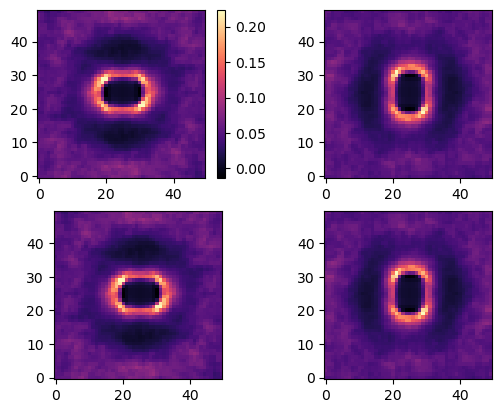

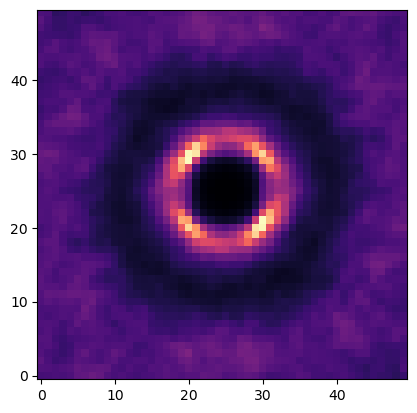

In [44]:
# create lattice
system_length = 20
lattice_type = "voronoi"
lattice = alter_lattice_maker(system_length, lattice_type)
lattice = koala.graph_utils.cut_boundaries(lattice, [False, True])

# set parameters, scan different values of J
t1 = 1  # orbital parallel neighbor hopping
t2 = 0.5  # orbital perpendicular neighbor hopping
filling = 0.3  # filling of the lattice
theta_offset = 0 #global rotation of the orbitals

 
hamiltonian = alt_hamiltonian(
        lattice,
        t1,
        t2,
        0,
        0,
        np.full(lattice.n_vertices, 0),
        np.full(lattice.n_vertices, filling)*4,
        theta_offset=0,
    )


# evaluating the Fermi energy
energies, states = la.eigh(hamiltonian)
fermi_energy = energies[
    int(filling * len(energies))
]  # better algorithm to get Fermi energy


fig,axs = plt.subplots(2,2)
print(spectral_function(lattice,energies,states,fermi_energy,local_operator=np.array([1,0,0,0]),eta=1e-2,n_k=30,).min())
im = axs[0,0].imshow(spectral_function(lattice,energies,states,fermi_energy,local_operator=np.array([1,0,0,0]),eta=1e-1,n_k=50,),cmap="magma",origin="lower")
plt.colorbar(im,ax=axs[0,0])
axs[0,1].imshow(spectral_function(lattice,energies,states,fermi_energy,local_operator=np.array([0,1,0,0]),eta=1e-1,n_k=50,),cmap="magma",origin="lower")
axs[1,0].imshow(spectral_function(lattice,energies,states,fermi_energy,local_operator=np.array([0,0,1,0]),eta=1e-1,n_k=50,),cmap="magma",origin="lower")
axs[1,1].imshow(spectral_function(lattice,energies,states,fermi_energy,local_operator=np.array([0,0,0,1]),eta=1e-1,n_k=50,),cmap="magma",origin="lower")
plt.show()

plt.imshow(spectral_function(lattice,energies,states,fermi_energy,local_operator=np.array([1,1,1,1]),eta=1e-1,n_k=50,),cmap="magma",origin="lower",)


In [37]:
from alter_morph.hamiltonians import _hopping_matrix
print(_hopping_matrix(1,0.5,0.2))
print(_hopping_matrix(1,0.5,0.2+np.pi))

[[-0.98026525 -0.09735459]
 [-0.09735459 -0.51973475]]
[[-0.98026525 -0.09735459]
 [-0.09735459 -0.51973475]]
